In [ ]:
#!pip install yfinance

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf


samsung_df = yf.download('005930.KS',
                      start='2022-01-01',
                      end='2025-11-21',
                      progress=False)

samsung_df = samsung_df[["Close"]]

samsung_df = samsung_df.reset_index()

samsung_df.columns = ['day', 'price']

samsung_df['day'] = pd.to_datetime(samsung_df['day'])

samsung_df.index = samsung_df['day']
samsung_df.set_index('day', inplace=True)

samsung_df

/tmp/ipython-input-1904657162.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  samsung_df = yf.download('005930.KS',


,price
day,
2022-01-04,72439.671875
2022-01-05,71243.070312
2022-01-06,70782.867188
2022-01-07,72071.492188
2022-01-10,71795.359375
...,...
2025-11-14,97200.000000
2025-11-17,100600.000000
2025-11-18,97800.000000


In [ ]:
samsung_train_df = samsung_df[:940]
samsung_train_df

,price
day,
2022-01-04,72439.671875
2022-01-05,71243.070312
2022-01-06,70782.867188
2022-01-07,72071.492188
2022-01-10,71795.359375
...,...
2025-11-05,100600.000000
2025-11-06,99200.000000
2025-11-07,97900.000000


In [ ]:
samsung_test_df = samsung_df[940:]
samsung_test_df

,price
day,
2025-11-12,103100.0
2025-11-13,102800.0
2025-11-14,97200.0
2025-11-17,100600.0
2025-11-18,97800.0
2025-11-19,96500.0
2025-11-20,100600.0


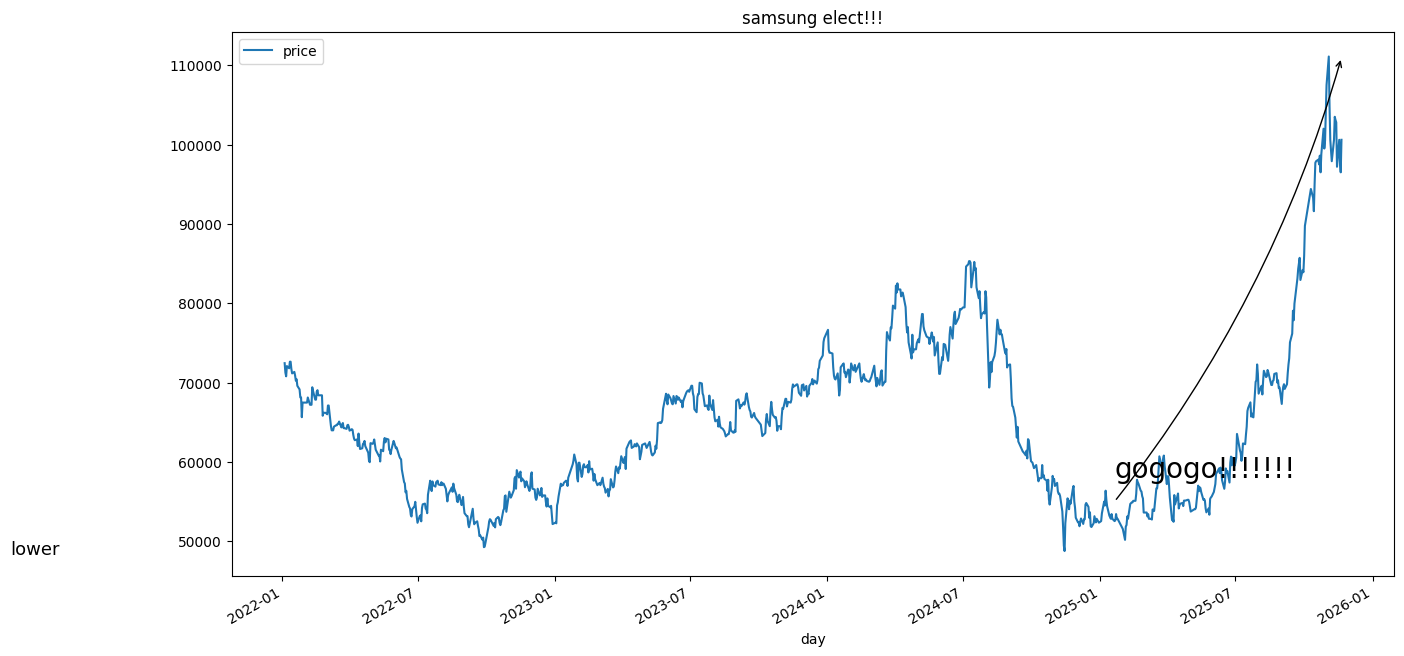

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))
samsung_df.plot(ax=ax)

# 4만 최저점
ax.annotate('', xy=('2022-03-23' ,42500.0), xytext=('2022-02-01', 48300.0),
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="arc3,rad=0.2"),
           )

plt.text('2021-01-01',48300, "lower",fontsize=13)

# 9만
ax.annotate('', xy=('2025-11-20' ,111000.0), xytext=('2025-01-20', 55000),
            arrowprops=dict(arrowstyle="->",
                            connectionstyle="arc3,rad=0.1"),
           )

plt.text('2025-01-20',58000, "gogogo!!!!!!!",fontsize=20)

plt.title("samsung elect!!!")
plt.show()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# 1) 시계열 준비 (인덱스 유지 권장)
series = samsung_train_df["price"]

# 2) ARIMA(2,1,2) 모델 적합
model = ARIMA(series, order=(2, 1, 0))  # (p, d, q)
model_fit = model.fit()

# 3) 요약 출력
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  940
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -7963.233
Date:                Wed, 26 Nov 2025   AIC                          15932.465
Time:                        22:06:55   BIC                          15947.000
Sample:                             0   HQIC                         15938.006
                                - 940                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0128      0.015      0.866      0.386      -0.016       0.042
ar.L2         -0.0394      0.019     -2.121      0.034      -0.076      -0.003
sigma2      1.352e+06   3.71e+04     36.410      0.0

1. 위쪽 기본 정보

Dep. Variable: price
→ 예측하려는 대상 변수 이름(여기서는 price).

No. Observations: 317
→ 사용한 데이터 개수(관측치 수).

Model: ARIMA(2, 1, 2)
→ AR(2), 차분 1번, MA(2) 쓴 ARIMA 모델.

Log Likelihood
→ 모델이 데이터를 얼마나 잘 설명하는지 나타내는 값(클수록 보통 좋음).

AIC / BIC / HQIC
→ “모델 적합도 + 모델 복잡도”를 함께 본 점수.
값이 작을수록 더 좋은 모델이라고 보통 비교함.

Covariance Type: opg
→ 계수 추정에 사용한 공분산 계산 방법(기술적인 설정, 보통 신경 안 써도 됨).





---



2. 계수 표 (ar.L1, ar.L2, ma.L1, ma.L2, sigma2)

각 행 = 모델의 계수
각 열 의미:

coef
→ 해당 항의 추정 계수 값.
(예: ar.L2 계수가 크고 유의하면 “2시점 전 값이 현재에 영향을 크게 준다”는 뜻)

std err
→ 계수 추정의 표준오차. (계수의 불확실성 크기)

z
→ 계수 / 표준오차 로 만든 통계량. (크면 클수록 “0이 아니다” 쪽 증거)

P>|z|
→ p-value.
보통 **0.05보다 작으면 “유의하다(중요한 계수다)”**라고 해석.

[0.025, 0.975]
→ 95% 신뢰구간.
이 구간에 0이 안 들어가면 보통 “유의한 계수”로 본다.

sigma2
→ 잔차(오차) 분산 추정값.
값이 작을수록 예측 오차가 작다고 볼 수 있음(단위는 데이터 스케일 따라감).



---



3. 아래쪽 진단 통계

Ljung-Box (L1) Q / Prob(Q)
→ 잔차에 자동상관이 남아 있는지 검사.
Prob(Q)가 크면(예: 0.89) → “잔차가 거의 랜덤, 모델이 시계열 패턴을 잘 잡았다” 정도로 봄.

Jarque-Bera (JB) / Prob(JB)
→ 잔차가 정규분포에 가까운지 검사.
Prob(JB)가 작으면 정규성에서 벗어난다는 뜻.

Heteroskedasticity (H) / Prob(H)
→ 잔차의 분산이 일정한지(등분산성) 검사.

Skew
→ 잔차 분포의 비대칭 정도(0이면 완전히 대칭).

Kurtosis
→ 잔차 분포의 뾰족함. 3보다 크면 꼬리가 두꺼운 분포라고 볼 수 있음.

Warnings
→ 추정 과정에서의 주의사항(여기선 “gradient로 공분산을 계산했다”는 정도).

In [ ]:
# 향후 30일 예측
forecast = model_fit.get_forecast(steps=10)
pred_mean = forecast.predicted_mean
pred_ci = forecast.conf_int()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
print("예측평균 --------------\n", pred_mean) #상위 예측값 + 하위 예측값 평균
print("예측값 -------------\n", pred_ci) #상위 예측값 + 하위 예측값

예측평균 --------------
 940    103430.573422
941    103315.378573
942    103316.645463
943    103321.202253
944    103321.210453
945    103321.030943
946    103321.028329
947    103321.035372
948    103321.035564
949    103321.035289
Name: predicted_mean, dtype: float64
예측값 -------------
        lower price    upper price
940  101151.563998  105709.582845
941  100071.747309  106559.009837
942   99386.831037  107246.459888
943   98809.484815  107832.919690
944   98292.964169  108349.456737
945   97824.529733  108817.532153
946   97393.196850  109248.859808
947   96991.200047  109650.870696
948   96613.243986  110028.827143
949   96255.476429  110386.594149


비트코인/엔비디아처럼

폭등이 있음

변동성이 크고

장기 상승추세가 있음

이런 자산은 ARIMA가 추세를 못 따라가고 평평하게 예측함 → 실제보다 낮음.

In [ ]:
# !pip install prophet

In [ ]:
samsung_df

,price
day,
2022-01-04,72439.671875
2022-01-05,71243.070312
2022-01-06,70782.867188
2022-01-07,72071.492188
2022-01-10,71795.359375
...,...
2025-11-14,97200.000000
2025-11-17,100600.000000
2025-11-18,97800.000000


In [ ]:
from prophet import Prophet



# 데이터프레임 준비 (인덱스를 'ds' 컬럼으로 변환)
samsung_df = samsung_df.reset_index()
samsung_df.columns = ['ds', 'y']

# 날짜 형식 확인 및 변환
samsung_df['ds'] = pd.to_datetime(samsung_df['ds'])

# train/test 분할 (비율 기반으로 개선)
train_size = 940
samsung_train_df = samsung_df[:train_size].copy()
samsung_test_df = samsung_df[train_size:].copy()

# 데이터 확인
print(f"전체 데이터: {len(samsung_df)}개")
print(f"학습 데이터: {len(samsung_train_df)}개")
print(f"테스트 데이터: {len(samsung_test_df)}개")
print(f"\n학습 기간: {samsung_train_df['ds'].min()} ~ {samsung_train_df['ds'].max()}")
print(f"테스트 기간: {samsung_test_df['ds'].min()} ~ {samsung_test_df['ds'].max()}")

전체 데이터: 947개
학습 데이터: 940개
테스트 데이터: 7개

학습 기간: 2022-01-04 00:00:00 ~ 2025-11-11 00:00:00
테스트 기간: 2025-11-12 00:00:00 ~ 2025-11-20 00:00:00


In [ ]:
prophet = Prophet(seasonality_mode = 'multiplicative',
                 yearly_seasonality=True,
                 weekly_seasonality=True,
                 daily_seasonality=True,
                 changepoint_prior_scale=0.5)

prophet.fit(samsung_train_df)

In [ ]:
future_data = prophet.make_future_dataframe(periods = 50, freq = 'd')
forecast_data = prophet.predict(future_data)
forecast_data[['ds','yhat', 'yhat_lower', 'yhat_upper']].tail(5)

,ds,yhat,yhat_lower,yhat_upper
985,2025-12-27,96809.401223,90060.984694,103577.816963
986,2025-12-28,96806.187828,89312.181297,103917.405746
987,2025-12-29,109723.013106,100643.707638,118288.213163
988,2025-12-30,109792.500342,100585.939454,117835.208937
989,2025-12-31,109850.878657,100654.653249,118426.532946


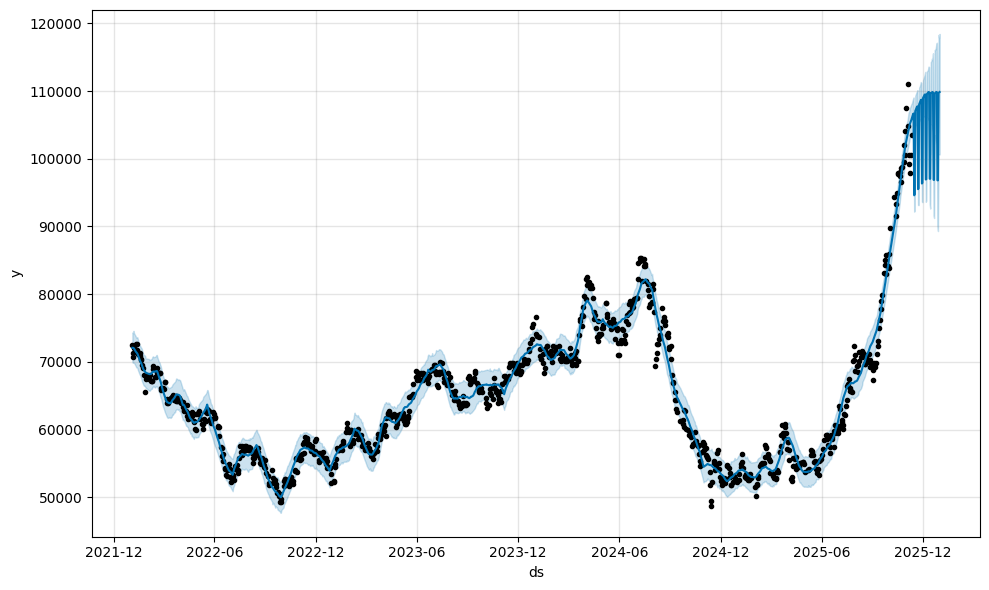

In [ ]:
fig1 = prophet.plot(forecast_data)

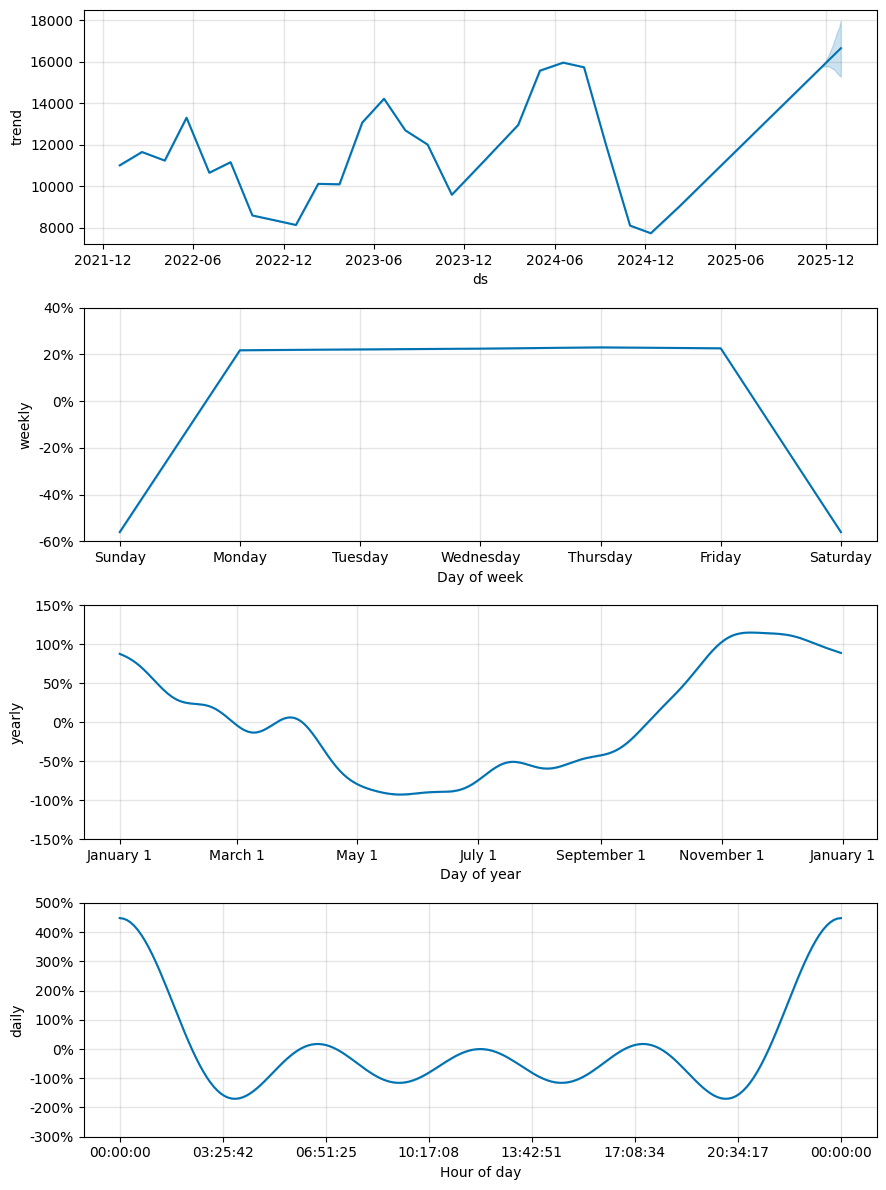

In [ ]:
fig2 = prophet.plot_components(forecast_data)

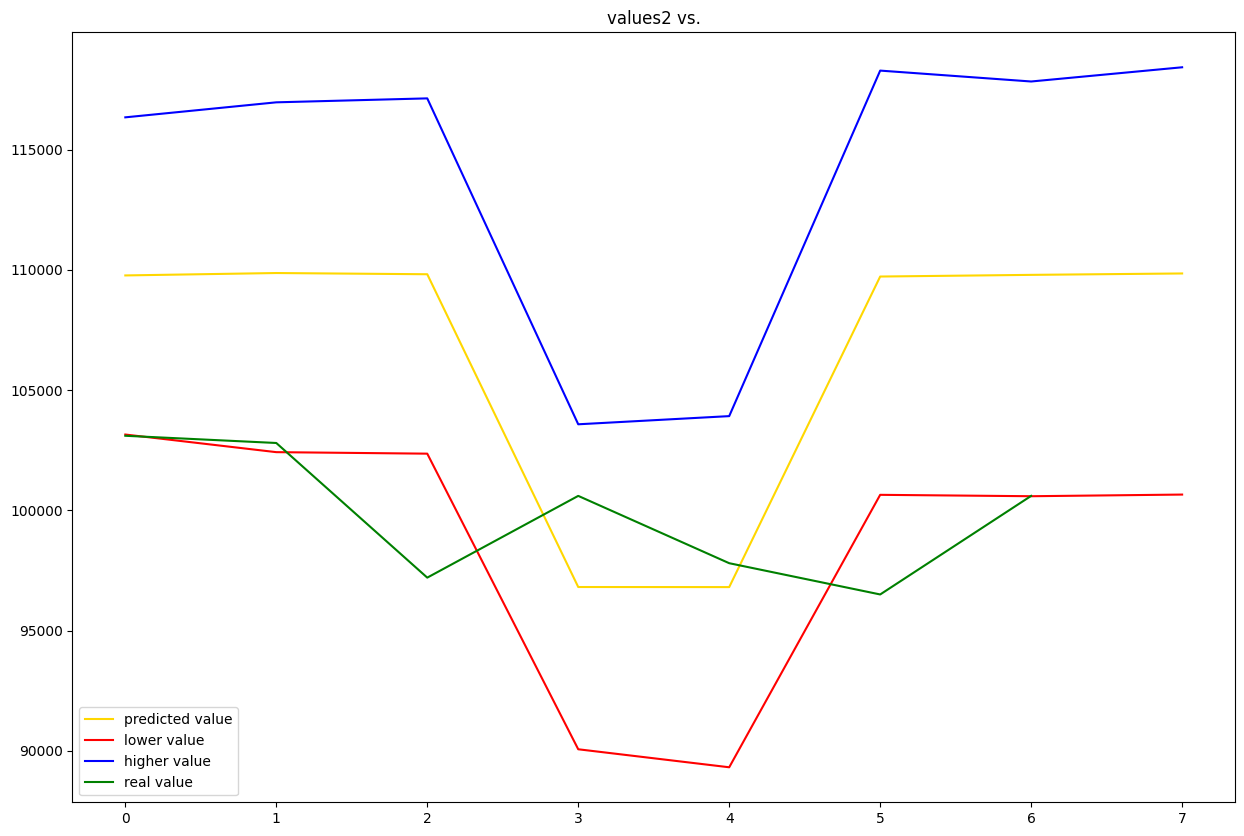

In [ ]:
plt.figure(figsize=(15, 10))

# 마지막 5일의 예측 데이터
pred_fbprophet_y = forecast_data.yhat.values[-8:]

# 실제 5일의 데이터
test_y = samsung_test_df.y.values

# 마지막 5일의 예측 데이터 최소값
pred_y_lower = forecast_data.yhat_lower.values[-8:]
# 마지막 5일의 예측 데이터 최대값
pred_y_upper = forecast_data.yhat_upper.values[-8:]

# 모델이 예측한 가격 그래프
plt.plot(pred_fbprophet_y, color = 'gold')

# 모델이 예측한 최저 가격 그래프
plt.plot(pred_y_lower, color = 'red')

# 모델이 예측한 최고 가격 그래프
plt.plot(pred_y_upper, color = 'blue')

# 실제 가격 그래프
plt.plot(test_y, color = 'green')

plt.legend(['predicted value', 'lower value','higher value','real value'])
plt.title("values2 vs.")
plt.show()

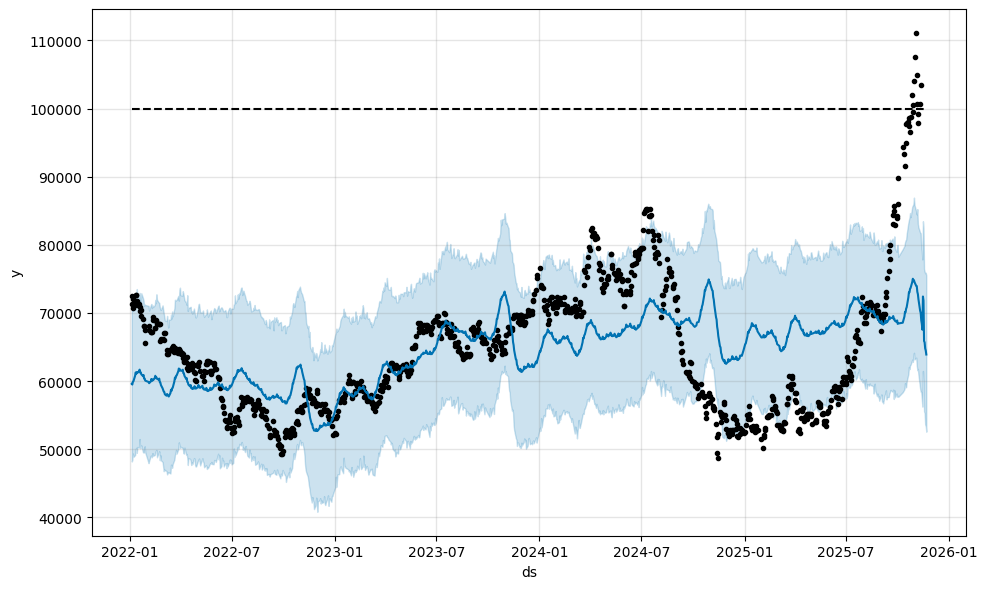

In [ ]:
# 상한가 설정
samsung_train_df['cap'] = 100000

# 상한가 적용을 위한 파라미터를 다음과 같이 설정
prophet = Prophet(seasonality_mode = 'multiplicative',
                 growth = 'logistic',
                 yearly_seasonality = True,
                 weekly_seasonality = True,
                 daily_seasonality = True,
                 changepoint_prior_scale = 0.5)

prophet.fit(samsung_train_df)

# 5일 예측
future_data = prophet.make_future_dataframe(periods = 10, freq = 'd')

# 상한가 설정
future_data['cap'] = 100000
forecast_data = prophet.predict(future_data)

fig = prophet.plot(forecast_data)

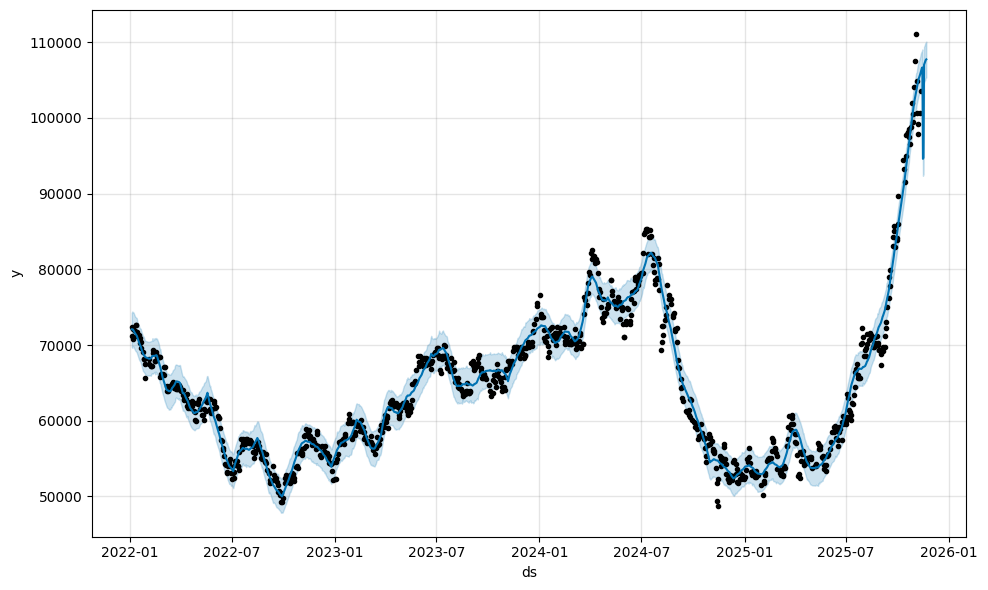

In [ ]:
samsung_train_df.loc[samsung_train_df['y'] > 120000, 'y'] = None

# prophet 모델 학습
prophet = Prophet(seasonality_mode = 'multiplicative',
                 yearly_seasonality = True,
                 weekly_seasonality = True,
                 daily_seasonality = True,
                 changepoint_prior_scale = 0.5)

prophet.fit(samsung_train_df)

# 10일 예측
future_data = prophet.make_future_dataframe(periods = 10, freq = 'd')

forecast_data = prophet.predict(future_data)

fig = prophet.plot(forecast_data)